In [ ]:
%pip install -q wandb
# !wandb login
# c44fdddfecae9d75682399ff1644ac20985484ee

In [1]:
!git clone https://github.com/clausmichele/CBSD68-dataset

Cloning into 'CBSD68-dataset'...
remote: Enumerating objects: 564, done.
remote: Total 564 (delta 0), reused 0 (delta 0), pack-reused 564 (from 1)
Receiving objects: 100% (564/564), 181.30 MiB | 16.42 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [1]:
from dataset import load_datasets, show
from model import DnCNN
from train import Trainer

/usr/lib/python3/dist-packages/requests/__init__.py:87: RequestsDependencyWarning: urllib3 (2.3.0) or chardet (4.0.0) doesn't match a supported version!
  warnings.warn("urllib3 ({}) or chardet ({}) doesn't match a supported "


In [2]:
# RTC:CBSD68-dataset/CBSD68/noisy35
train_d, test_d = load_datasets('CBSD68-dataset/CBSD68/noisy35', 'CBSD68-dataset/CBSD68/original_png')

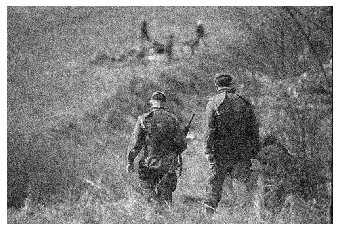

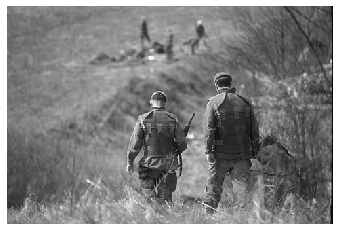

(None, None)

In [3]:
show(train_d[17][0]), show(train_d[17][1])

In [4]:
import gc
import torch
gc.collect()
torch.cuda.empty_cache()

In [5]:
def hyperparameter_tuning(train_loader, test_loader, save_dir="models", wandb_project="dncnn-tuning", wandb_entity=None):
    sweep_config = {
        "method": "random",
        "metric": {"name": "val_loss", "goal": "minimize"},
        "parameters": {
            "batch_size": {"values": [4, 8, 16]},
            "learning_rate": {"distribution": "log_uniform_values", "min": 1e-4, "max": 1e-2},
            "epochs": {"values": [50, 100, 150]},
            "patience": {"values": [5, 10, 15]}
        }
    }
    sweep_id = wandb.sweep(sweep_config, project=wandb_project, entity=wandb_entity)

    def train_sweep(config=None):
        with wandb.init(config=config):
            config = wandb.config  # Access the current sweep config

            print(f'\n {config}')

            model = DnCNN()  # Replace with your actual model
            trainer = Trainer(
                model, train_loader, test_loader, save_dir, 
                batch_size=config.batch_size, 
                lr=config.learning_rate, 
                n_epoch=config.epochs, 
                patience=config.patience,
                wandb_project=wandb_project, 
                wandb_entity=wandb_entity
            )
            trainer.train()
    
    wandb.agent(sweep_id, train_sweep, count=10)

In [6]:
import wandb
hyperparameter_tuning(train_d, test_d)

Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Create sweep with ID: nq0xpg89
Sweep URL: https://wandb.ai/firefly334/dncnn-tuning/sweeps/nq0xpg89


wandb: Agent Starting Run: 7ykgud59 with config:
wandb: 	batch_size: 8
wandb: 	epochs: 150
wandb: 	learning_rate: 0.00023794286749155796
wandb: 	patience: 5
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: omkar334 (firefly334) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin



 {'batch_size': 8, 'epochs': 150, 'learning_rate': 0.00023794286749155796, 'patience': 5}


/usr/lib/python3/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


...

wandb: Agent Starting Run: 8xxcx92p with config:
wandb: 	batch_size: 8
wandb: 	epochs: 100
wandb: 	learning_rate: 0.000818907839683107
wandb: 	patience: 15
Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.



 {'batch_size': 8, 'epochs': 100, 'learning_rate': 0.000818907839683107, 'patience': 15}


/usr/lib/python3/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


2025-03-21 06:40:14: Epoch 1: Train Loss = 157628.8108, Val Loss = 126507.1484, Time = 1.21s
model saved
2025-03-21 06:40:16: Epoch 2: Train Loss = 13953.9406, Val Loss = 13855.7373, Time = 1.18s
model saved
2025-03-21 06:40:17: Epoch 3: Train Loss = 6198.1565, Val Loss = 6304.0708, Time = 1.18s
model saved
2025-03-21 06:40:18: Epoch 4: Train Loss = 5271.5319, Val Loss = 5061.6709, Time = 1.18s
model saved
2025-03-21 06:40:20: Epoch 5: Train Loss = 5053.2376, Val Loss = 4363.4214, Time = 1.18s
model saved
2025-03-21 06:40:21: Epoch 6: Train Loss = 4885.3206, Val Loss = 4969.5803, Time = 1.18s
2025-03-21 06:40:23: Epoch 7: Train Loss = 4762.1805, Val Loss = 4280.3408, Time = 1.18s
model saved
2025-03-21 06:40:24: Epoch 8: Train Loss = 4696.9881, Val Loss = 4455.1418, Time = 1.18s
2025-03-21 06:40:25: Epoch 9: Train Loss = 4667.4419, Val Loss = 4244.3184, Time = 1.18s
model saved
2025-03-21 06:40:27: Epoch 10: Train Loss = 4642.6507, Val Loss = 4202.8398, Time = 1.18s
model saved
2025-03

epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
time,▂▂▂▂▅▁▂▄▂▁▁▃▃▂▂▂▄█▄▃▄▃▂▅▃▄▂▅▃▃▃▃▃▃▅▅▃▄▃▂
train_loss,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_loss,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,100
time,1.17671
train_loss,4476.05744
val_loss,4133.34375
